## Predictions

```{mermaid}
%%| eval: true
flowchart TD
    A@{ shape: cyl, label: "Copernicus Data Space Ecosystem"} -->  B@{ shape: docs, label: "Sentinel-2 .SAFE" }
    B --> C@{ shape: docs, label: "True Color Image" }
    B --> D@{ shape: process, label: "omnicloudmask"} --> E@{ shape: docs, label: "Cloud masks" }
    C --> F@{ shape: process, label: "ultralytics & sahi"} --> G@{ shape: docs, label: "Detections" }
    G --> H@{ shape: process, label: "Removing stationary targets"}  --> I@{ shape: docs, label: "Filtered detections"}
    J@{ shape: cyl, label: "Topographic database"} --> H
    K@{ shape: cyl, label: "Aids to navigation"} --> H
    L@{ shape: cyl, label: "Fisheries"} --> H
    I --> M@{ shape: process, label: "Spatial aggregation"} --> N@{ shape: docs, label: "Spatial statistics"}
    E --> M
```

First import the required packages. sahi is used for tiled inference.

In [11]:
import sys, os
from pathlib import Path
import torch
import geopandas as gpd
import pandas as pd
import shapely
import matplotlib.pyplot as plt
from sahi.models.ultralytics import UltralyticsDetectionModel
import rasterio as rio
import rasterio.plot as rioplot
from sahi.predict import get_sliced_prediction
sys.path.insert(1, '..')

from src.sahi_utils import *

Set the model path, data path, device and other parameters:

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
half = True
model_path = '../hf/marine-vessel-detection/pretrained/yolov8s.pt' # Location for the checkpoint to use
conf_th = 0.338 # confidence threshold with highest validation F1-score

Then initialize UltralyticsDetectionModel and overrides for the model.

In [3]:
det_model = UltralyticsDetectionModel(model_path=model_path,
                                      device=device,
                                      confidence_threshold=conf_th,
                                      image_size=640)

det_model.model.overrides.update({'half': half})

Now get_sliced_prediction can be used to perform tiled inference for the tile:

In [4]:
tile = '../dataset/rgb_mosaics/34VEN/S2A_MSIL1C_20220624T100041_N0510_R122_T34VEN_20240714T110124.tif'

sliced_pred_results = get_sliced_prediction(tile, det_model, slice_width=320, slice_height=320,
                                            overlap_height_ratio=0.2, overlap_width_ratio=0.2, perform_standard_pred=False,
                                            verbose=2)

Performing prediction on 1849 slices.
Slicing performed in 4.380781953994301 seconds.
Prediction performed in 17.219352370972047 seconds.
Postprocessing performed in 0.04377245903015137 seconds.


In [21]:
georef_preds = georef_sahi_preds(preds=sliced_pred_results.object_prediction_list, path_to_ref_img=tile)
georef_preds['class_name'] = 'boat'
georef_preds.head()

,label,geometry,score,class_name
0,0,"POLYGON ((519777.5 6765886.25, 519777.5 676584...",0.741699,boat
1,0,"POLYGON ((515027.5 6774092.812, 515027.5 67739...",0.735840,boat
2,0,"POLYGON ((569162.5 6695266.25, 569162.5 669522...",0.729492,boat
3,0,"POLYGON ((518553.125 6740162.5, 518553.125 674...",0.716797,boat
4,0,"POLYGON ((554097.188 6699215, 554097.188 66991...",0.716797,boat


Plot the data:

<Axes: >

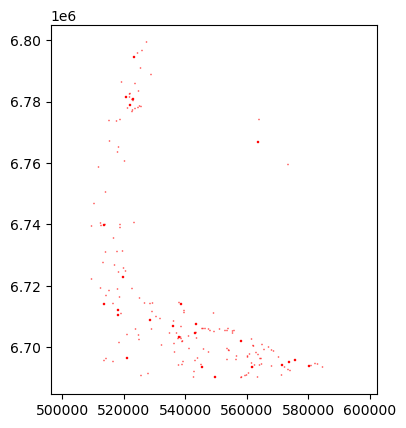

In [22]:
georef_preds.plot(facecolor='none', edgecolor='red')


## Cleaning stationary targets

We use external data to filter out known false positives, such as windmills, above water rocks, and beacons, as well as to filter some predictions that fall on land. Data for beacons can be accessed via the Finnish Transport Infrastructure Agency portal [Suomen Väylät](https://suomenvaylat.vayla.fi/?lang=en) and layer Aids to navigation. Other data used for cleaning is [Topographic database](https://asiointi.maanmittauslaitos.fi/karttapaikka/tiedostopalvelu/maastotietokanta?lang=en) by the National Land Survey of Finland.

Note: Topographic database is around 50GB geopackage. Required layers are around 2.5GB as gpkg files and 1.7GB as geoparquet files.

### Detection not on water

This step filters the detections whose centroid points are on land. The layers jarvi (lakes), meri (sea) and virtavesialue (rivers etc) are used here. The data are on `epsg:3067`.

In [23]:
def read_geopandas_file(fname=Path, layer=None, bbox=None):
    "Read file depending on the suffix"
    if fname.suffix == '.parquet':
        return gpd.read_parquet(fname).clip(box(*bbox))
    else:
        return gpd.read_file(fname, bbox=bbox)


tot_bounds_3067 = tuple(georef_preds.to_crs('EPSG:3067').total_bounds)

lakes = read_geopandas_file(Path('../data/mtk/lakes.parquet'), bbox=tot_bounds_3067)
seas = read_geopandas_file(Path('../data/mtk/seas.parquet'), bbox=tot_bounds_3067)
rivers = read_geopandas_file(Path('../data/mtk/rivers.parquet'), bbox=tot_bounds_3067)
lakes = lakes.to_crs(georef_preds.crs)
seas = seas.to_crs(georef_preds.crs)
rivers = rivers.to_crs(georef_preds.crs)
waters = pd.concat([lakes, seas, rivers])

Filtering is done by

1. changing the geometries of the predictions to their centroid points
2. keep only the geometries which are located on water

In [24]:
georef_preds['centroids'] = georef_preds.centroid
georef_preds.set_geometry('centroids', inplace=True)
joined = georef_preds.sjoin(waters, how='inner', predicate='within')[['label', 'score', 'geometry', 'centroids', 'class_name']]
georef_preds.loc[~georef_preds.index.isin(joined.index), 'class_name'] = 'land'

Known side effect for this is that it flags detections outside of Finnish territorial waters as `land`.

### Detections on above water rock areas

There are two types of above water rock reference geometries: area (layer vesikivikko) and points (few target classes in layer vesikivi). Both are filtered from the data, but the point data is filtered at a later step.

vesikivikko works same way than filtering based on water:

In [25]:
rocks = read_geopandas_file(Path('../data/mtk/water_rock_areas.parquet'), bbox=tot_bounds_3067)
rocks = rocks.to_crs(georef_preds.crs)

joined = gpd.sjoin(georef_preds, rocks, predicate='within', how='inner')[['label', 'score', 'geometry', 'centroids', 'class_name']]
georef_preds.loc[georef_preds.index.isin(joined.index), 'class_name'] = 'area_rocks'

### Fisheries

There is no available data for the locations of fisheries, so those data are manually derived from aerial images and satellite data.

In [27]:
fisheries = read_geopandas_file(Path('../data/fisheries_3067.gpkg'), bbox=tot_bounds_3067)
fisheries = fisheries.to_crs(georef_preds.crs)

joined = gpd.sjoin(georef_preds, fisheries, predicate='within', how='inner')[['label', 'score', 'geometry', 'centroids', 'class_name']]
georef_preds.loc[georef_preds.index.isin(joined.index), 'class_name'] = 'fisheries'

### Individual large rocks

Now the geometry can be reverted to bounding boxes.



In [28]:
georef_preds = georef_preds.set_geometry('geometry')[['label', 'score', 'geometry', 'class_name']]

Then drop detections containing rocks above waterline within them

In [29]:
above_water_rocks = read_geopandas_file(Path('../data/mtk/water_rock_points.parquet'), bbox=tot_bounds_3067).to_crs(georef_preds.crs)
above_water_rocks = above_water_rocks[above_water_rocks.kohdeluokka.isin([38511,38512,38513])]
georef_preds.loc[(any(g.contains(above_water_rocks.geometry)) for g in georef_preds.geometry), 'class_name'] = 'rock'

Filtering windmills works like this, but in this tile there are none.

### Beacons

Sector lights, lighthouses and such beacons are visible from satellite images, and are confused with small vessels.

In [30]:
beacons = read_geopandas_file(Path('../data/vaylavirasto/turvalaitteetPoint.shp'), tot_bounds_3067).to_crs(georef_preds.crs)
beacons = beacons[beacons.ty_jnr.isin([1,2,3,4,5,8])]
georef_preds.loc[(any(g.contains(beacons.geometry)) for g in georef_preds.geometry), 'type'] = 'beacon'

/home/mayrajeo/miniforge3/envs/ship-env/lib/python3.12/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


### Size filtering

Finally drop obviously too large detections. They are really rare.

In [31]:
def get_longer_edge(geom:shapely.geometry.Polygon) -> float:
    x, y = shapely.geometry.box(*geom.bounds).exterior.coords.xy
    edge_lengths = (shapely.geometry.Point(x[0],y[0]).distance(shapely.geometry.Point(x[1],y[1])),
                    shapely.geometry.Point(x[1],y[1]).distance(shapely.geometry.Point(x[2],y[2])))
    return max(edge_lengths)

In [32]:
georef_preds['max_edge'] = georef_preds.geometry.apply(get_longer_edge)
georef_preds.loc[georef_preds.max_edge >= 750, 'class_name'] = 'size'

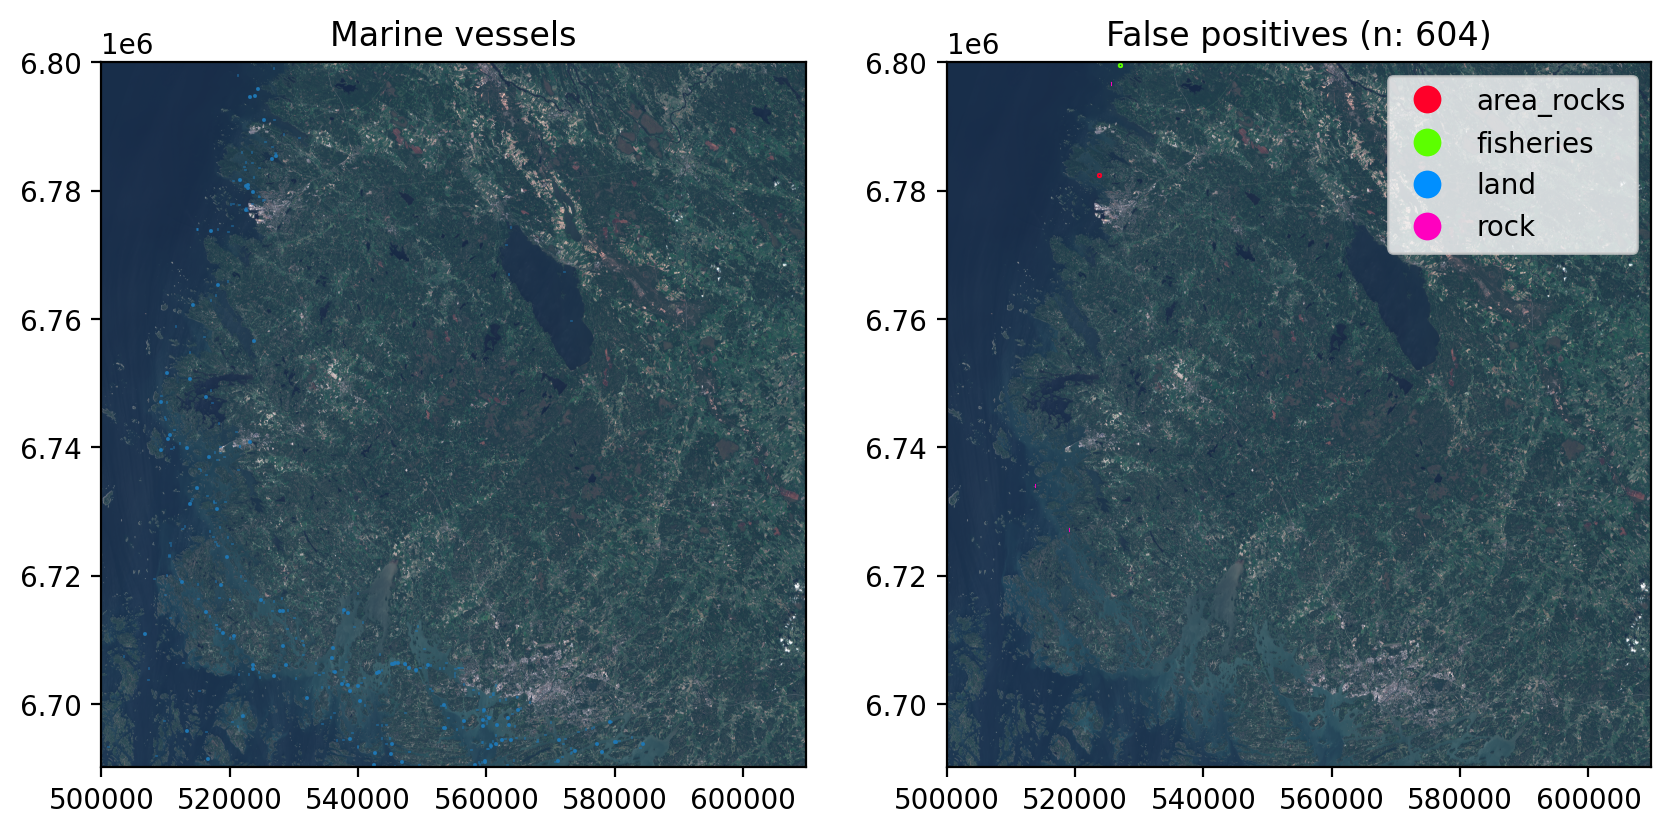

In [37]:
fig, axs = plt.subplots(1,2, dpi=200, figsize=(10,6))

with rio.open(tile) as src:
    rioplot.show(src, ax=axs[0])
    rioplot.show(src, ax=axs[1])
    
georef_preds[georef_preds['class_name'] == 'boat'].plot(ax=axs[0], column='class_name', facecolor='none')
georef_preds[georef_preds['class_name'] != 'boat'].plot(ax=axs[1], column='class_name', linewidth=1.5, facecolor='none', legend=True, cmap='gist_rainbow')
axs[0].set_title('Marine vessels')
axs[1].set_title(f"False positives (n: {len(georef_preds[georef_preds['type'] != 'boat'])})")
plt.show()